# 01 - Top-10 Finish Probability (XGBoost)

Predict probability a driver finishes in the Top 10 (points) using only pre-race information.

## 1) Setup + paths

In [2]:
from pathlib import Path
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "archive"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

MIN_TRAIN_YEAR = 2006
TRAIN_END_YEAR = 2021
VAL_YEAR = 2022
TEST_START_YEAR = 2023
TRAIN_FIT_VERBOSE = 100  # Set False to disable logs; int prints every N rounds

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

pd.set_option("display.max_columns", 120)
PROJECT_ROOT


PosixPath('/home/asen/Work/Uni Work/Година 3/Семестър 6/Програмиране за Мобилни Устройства/Data_Science_and_ML_part')

## 2) Load data (from `data/archive/`)

In [3]:
from src.data_load import get_year_coverage, list_csv_files, load_raw_tables, summarize_archive_schema

csv_files = list_csv_files(DATA_DIR)
tables = load_raw_tables(DATA_DIR)
archive_schema = summarize_archive_schema(DATA_DIR)
year_coverage = get_year_coverage(tables["races"])

print(f"Found {len(csv_files)} CSV files")
print("Year coverage:", year_coverage)
csv_files


Found 14 CSV files
Year coverage: {'min_year': 1950, 'max_year': 2025, 'years': [1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]}


['circuits.csv',
 'constructor_results.csv',
 'constructor_standings.csv',
 'constructors.csv',
 'driver_standings.csv',
 'drivers.csv',
 'lap_times.csv',
 'pit_stops.csv',
 'qualifying.csv',
 'races.csv',
 'results.csv',
 'seasons.csv',
 'sprint_results.csv',
 'status.csv']

## 3) Build dataset (joins + cleaning)

In [4]:
from src.features import build_pre_race_features

feature_df = build_pre_race_features(tables)
feature_df.head()


,raceId,year,round,date,driverId,constructorId,circuitId,driver_name,constructor_name,circuit_country,circuit_alt,circuit_lat,circuit_lng,grid,grid_missing,grid_zero,quali_position,q1_seconds,q2_seconds,q3_seconds,quali_position_gap_to_best,quali_position_gap_to_median,q1_seconds_gap_to_best,q1_seconds_gap_to_median,q2_seconds_gap_to_best,q2_seconds_gap_to_median,q3_seconds_gap_to_best,q3_seconds_gap_to_median,q2_minus_q1_seconds,q3_minus_q2_seconds,grid_delta_vs_teammate,quali_delta_vs_teammate,has_qualifying_data,qualifying_missing,driver_points_mean_last5,driver_finishpos_mean_last5,driver_top10_rate_last10,driver_dnf_rate_last20,team_points_mean_last5,team_top10_rate_last10,team_dnf_rate_last20,driver_avg_finish_at_circuit,driver_top10_rate_at_circuit,y_top10,y_dnf
0,833,1950,1,1950-05-13,579,51,9,Juan Fangio,Alfa Romeo,UK,153,52.0786,-1.01694,3.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.666667,NaN,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1
1,833,1950,1,1950-05-13,589,105,9,Louis Chiron,Maserati,UK,153,52.0786,-1.01694,11.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-3.500000,NaN,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1
2,833,1950,1,1950-05-13,619,151,9,Bob Gerard,ERA,UK,153,52.0786,-1.01694,13.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.250000,NaN,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0
3,833,1950,1,1950-05-13,627,154,9,Louis Rosier,Talbot-Lago,UK,153,52.0786,-1.01694,9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-3.000000,NaN,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0
4,833,1950,1,1950-05-13,640,105,9,Toulo de Graffenried,Maserati,UK,153,52.0786,-1.01694,8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-7.000000,NaN,0,1,NaN,NaN,NaN,NaN,0.0,0.0,1.0,NaN,NaN,0,1


In [13]:
# Save feature_df to CSV (Parquet has compatibility issues with current pandas/pyarrow versions)
csv_path = PROJECT_ROOT / "data" / "feature_df.csv"
feature_df.to_csv(csv_path, index=False)

print(f"Saved feature_df to {csv_path}")
print(f"Shape: {feature_df.shape}")
print(f"CSV size: {csv_path.stat().st_size / 1024 / 1024:.2f} MB")

Saved feature_df to /home/asen/Work/Uni Work/Година 3/Семестър 6/Програмиране за Мобилни Устройства/Data_Science_and_ML_part/data/feature_df.csv
Shape: (27238, 45)
CSV size: 5.42 MB


## 4) Feature engineering (call `src/features.py`)

In [7]:
from src.features import get_categorical_features, get_feature_columns

feature_columns = get_feature_columns(feature_df)
categorical_columns = get_categorical_features(feature_df)
numeric_columns = [column for column in feature_columns if column not in categorical_columns]
target_column = "y_top10"

print("Feature count:", len(feature_columns))
print("Categorical:", categorical_columns)
feature_columns


Feature count: 39
Categorical: ['driverId', 'constructorId', 'circuitId', 'circuit_country']


['year',
 'round',
 'circuitId',
 'circuit_country',
 'circuit_alt',
 'circuit_lat',
 'circuit_lng',
 'driverId',
 'constructorId',
 'grid',
 'grid_missing',
 'grid_zero',
 'quali_position',
 'q1_seconds',
 'q2_seconds',
 'q3_seconds',
 'quali_position_gap_to_best',
 'quali_position_gap_to_median',
 'q1_seconds_gap_to_best',
 'q1_seconds_gap_to_median',
 'q2_seconds_gap_to_best',
 'q2_seconds_gap_to_median',
 'q3_seconds_gap_to_best',
 'q3_seconds_gap_to_median',
 'q2_minus_q1_seconds',
 'q3_minus_q2_seconds',
 'grid_delta_vs_teammate',
 'quali_delta_vs_teammate',
 'has_qualifying_data',
 'qualifying_missing',
 'driver_points_mean_last5',
 'driver_finishpos_mean_last5',
 'driver_top10_rate_last10',
 'driver_dnf_rate_last20',
 'team_points_mean_last5',
 'team_top10_rate_last10',
 'team_dnf_rate_last20',
 'driver_avg_finish_at_circuit',
 'driver_top10_rate_at_circuit']

## 5) Split (call `src/split.py`)

In [8]:
from src.split import season_time_split

splits = season_time_split(
    feature_df,
    train_end_year=TRAIN_END_YEAR,
    min_train_year=MIN_TRAIN_YEAR,
    val_year=VAL_YEAR,
    test_start_year=TEST_START_YEAR,
)

{k: v.shape for k, v in splits.items()}


{'train': (6555, 45), 'val': (440, 45), 'test': (1398, 45)}

## 6) Train (call `src/train.py`)

In [10]:
from src.train import train_xgb_pipeline

X_train = splits["train"][feature_columns]
y_train = splits["train"][target_column]
X_val = splits["val"][feature_columns]
y_val = splits["val"][target_column]

trained = train_xgb_pipeline(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    categorical_columns=categorical_columns,
    numeric_columns=numeric_columns,
    model_params=None,
    early_stopping_rounds=50,
    fit_verbose=TRAIN_FIT_VERBOSE,
)

pipeline = trained["pipeline"]
trained["params"]


[0]	validation_0-logloss:0.67808
[100]	validation_0-logloss:0.50185
[107]	validation_0-logloss:0.50063


{'objective': 'binary:logistic',
 'n_estimators': 2000,
 'learning_rate': 0.05,
 'max_depth': 5,
 'subsample': 0.8,
 'colsample_bytree': 0.8,
 'reg_lambda': 1.0,
 'reg_alpha': 0.0,
 'eval_metric': 'logloss',
 'tree_method': 'hist',
 'n_jobs': -1,
 'random_state': 42,
 'early_stopping_rounds': 50}

## 7) Evaluate (call `src/eval.py`)

In [11]:
from src.eval import (
    evaluate_all_splits,
    find_best_threshold,
    metrics_table,
    plot_calibration_curve,
    threshold_sweep,
)

# Baseline metrics at threshold 0.5
baseline_results = evaluate_all_splits(
    pipeline=pipeline,
    splits=splits,
    feature_columns=feature_columns,
    target_column=target_column,
    threshold=0.5,
)

# Tune threshold on validation split (default metric: F1)
threshold_candidates = threshold_sweep(
    baseline_results["val"]["y_true"],
    baseline_results["val"]["y_prob"],
)

tuned_threshold_info = find_best_threshold(
    baseline_results["val"]["y_true"],
    baseline_results["val"]["y_prob"],
    metric="f1",
)
tuned_threshold = tuned_threshold_info["best_threshold"]
print(f"Using tuned threshold from validation: {tuned_threshold:.2f} (best val F1={tuned_threshold_info['best_metric_value']:.4f})")

# Final evaluation at tuned threshold
evaluation_results = evaluate_all_splits(
    pipeline=pipeline,
    splits=splits,
    feature_columns=feature_columns,
    target_column=target_column,
    threshold=tuned_threshold,
)

metrics_df_baseline = metrics_table(baseline_results)
metrics_df = metrics_table(evaluation_results)

print("Baseline metrics @ threshold=0.50")
display(metrics_df_baseline)
print(f"Tuned metrics @ threshold={tuned_threshold:.2f}")
display(metrics_df)

threshold_candidates.sort_values("f1", ascending=False).head(10)


Using tuned threshold from validation: 0.41 (best val F1=0.8017)
Baseline metrics @ threshold=0.50


,split,roc_auc,pr_auc,log_loss,brier_score,threshold,precision,recall,f1,confusion_matrix,precision_at_0_5,recall_at_0_5,f1_at_0_5,confusion_matrix_at_0_5,rows
0,train,0.902865,0.881951,0.406780,0.128834,0.5,0.788047,0.833225,0.810006,"{'tn': 2797, 'fp': 688, 'fn': 512, 'tp': 2558}",0.788047,0.833225,0.810006,"{'tn': 2797, 'fp': 688, 'fn': 512, 'tp': 2558}",6555
1,val,0.838533,0.802916,0.497487,0.160249,0.5,0.777293,0.809091,0.792873,"{'tn': 169, 'fp': 51, 'fn': 42, 'tp': 178}",0.777293,0.809091,0.792873,"{'tn': 169, 'fp': 51, 'fn': 42, 'tp': 178}",440
2,test,0.872245,0.859993,0.462908,0.147531,0.5,0.777045,0.841429,0.807956,"{'tn': 529, 'fp': 169, 'fn': 111, 'tp': 589}",0.777045,0.841429,0.807956,"{'tn': 529, 'fp': 169, 'fn': 111, 'tp': 589}",1398


Tuned metrics @ threshold=0.41


,split,roc_auc,pr_auc,log_loss,brier_score,threshold,precision,recall,f1,confusion_matrix,rows
0,train,0.902865,0.881951,0.406780,0.128834,0.41,0.746118,0.892182,0.812639,"{'tn': 2553, 'fp': 932, 'fn': 331, 'tp': 2739}",6555
1,val,0.838533,0.802916,0.497487,0.160249,0.41,0.741313,0.872727,0.801670,"{'tn': 153, 'fp': 67, 'fn': 28, 'tp': 192}",440
2,test,0.872245,0.859993,0.462908,0.147531,0.41,0.725029,0.881429,0.795616,"{'tn': 464, 'fp': 234, 'fn': 83, 'tp': 617}",1398


,threshold,precision,recall,f1
36,0.41,0.741313,0.872727,0.801670
34,0.39,0.733840,0.877273,0.799172
35,0.40,0.733840,0.877273,0.799172
37,0.42,0.744094,0.859091,0.797468
40,0.45,0.760331,0.836364,0.796537
33,0.38,0.728302,0.877273,0.795876
38,0.43,0.750000,0.845455,0.794872
42,0.47,0.764706,0.827273,0.794760
32,0.37,0.721190,0.881818,0.793456
39,0.44,0.754098,0.836364,0.793103


## 7b) Confusion matrix visualization


/tmp/ipykernel_12989/3402383407.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


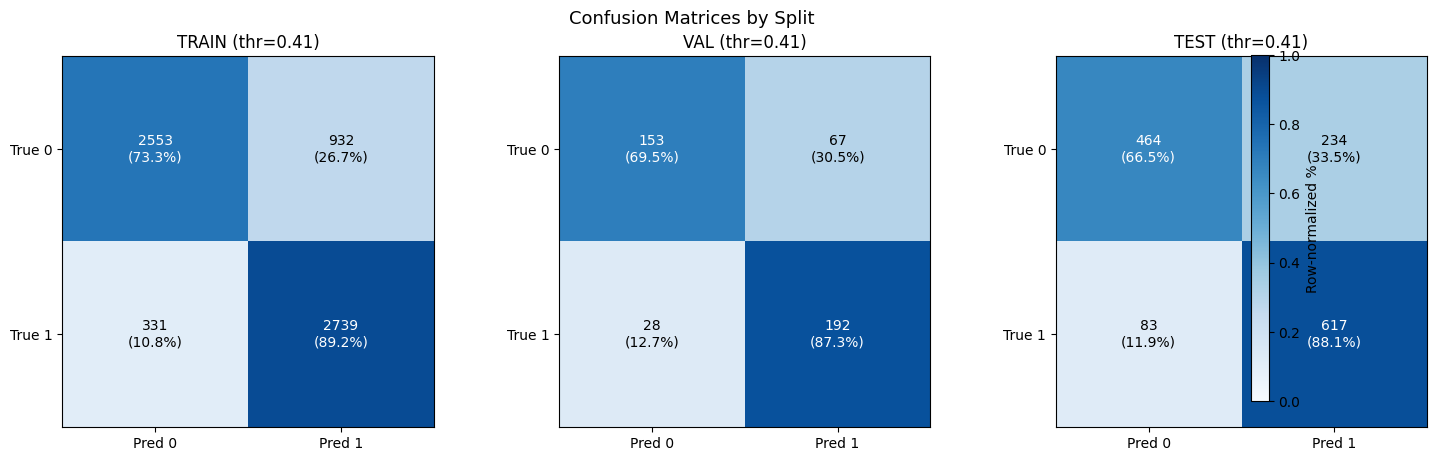

In [12]:
import numpy as np
import matplotlib.pyplot as plt


def _extract_confusion_matrix(metrics_dict):
    if "confusion_matrix" in metrics_dict:
        return metrics_dict["confusion_matrix"]
    if "confusion_matrix_at_0_5" in metrics_dict:
        return metrics_dict["confusion_matrix_at_0_5"]
    raise KeyError("No confusion matrix found in metrics dict.")


def _plot_confusion_from_metrics(eval_results, threshold=0.5):
    split_order = [name for name in ["train", "val", "test"] if name in eval_results]
    if not split_order:
        raise ValueError("No splits found in evaluation_results.")

    fig, axes = plt.subplots(1, len(split_order), figsize=(5 * len(split_order), 4.5))
    if len(split_order) == 1:
        axes = [axes]

    for axis, split_name in zip(axes, split_order):
        cm = _extract_confusion_matrix(eval_results[split_name]["metrics"])
        matrix = np.array([[cm["tn"], cm["fp"]], [cm["fn"], cm["tp"]]], dtype=float)

        row_sums = matrix.sum(axis=1, keepdims=True)
        matrix_norm = np.divide(matrix, row_sums, out=np.zeros_like(matrix), where=row_sums > 0)

        im = axis.imshow(matrix_norm, vmin=0.0, vmax=1.0, cmap="Blues")
        axis.set_title(f"{split_name.upper()} (thr={threshold:.2f})")
        axis.set_xticks([0, 1], labels=["Pred 0", "Pred 1"])
        axis.set_yticks([0, 1], labels=["True 0", "True 1"])

        for i in range(2):
            for j in range(2):
                count = int(matrix[i, j])
                pct = matrix_norm[i, j] * 100
                text_color = "white" if matrix_norm[i, j] > 0.5 else "black"
                axis.text(j, i, f"{count}\n({pct:.1f}%)", ha="center", va="center", color=text_color)

    cbar = fig.colorbar(im, ax=axes, fraction=0.035, pad=0.04)
    cbar.set_label("Row-normalized %")
    fig.suptitle("Confusion Matrices by Split", fontsize=13)
    fig.tight_layout()
    plt.show()


_plot_confusion_from_metrics(evaluation_results, threshold=tuned_threshold)


In [13]:
# Calibration plots (validation and test)
plot_calibration_curve(
    evaluation_results["val"]["y_true"],
    evaluation_results["val"]["y_prob"],
    title="Top10 Calibration - Validation",
    output_path=ARTIFACTS_DIR / "top10_calibration_val.png",
)
plot_calibration_curve(
    evaluation_results["test"]["y_true"],
    evaluation_results["test"]["y_prob"],
    title="Top10 Calibration - Test",
    output_path=ARTIFACTS_DIR / "top10_calibration_test.png",
)


(array([0.06542056, 0.08888889, 0.19727891, 0.24509804, 0.32692308,
        0.5       , 0.62411348, 0.8340081 , 0.91923077, 1.        ]),
 array([0.075132  , 0.14662006, 0.24912507, 0.34669585, 0.44550757,
        0.54679881, 0.65273976, 0.75945788, 0.83511953, 0.90279281]))

## 7c) Feature ablation (optional)


In [9]:
import pandas as pd

from src.eval import evaluate_all_splits, metrics_table
from src.train import compute_scale_pos_weight, train_xgb_pipeline

# New features added in the latest iteration.
ADDED_QUALI_FEATURES = [
    "quali_position_gap_to_best",
    "quali_position_gap_to_median",
    "q1_seconds_gap_to_best",
    "q1_seconds_gap_to_median",
    "q2_seconds_gap_to_best",
    "q2_seconds_gap_to_median",
    "q3_seconds_gap_to_best",
    "q3_seconds_gap_to_median",
    "q2_minus_q1_seconds",
    "q3_minus_q2_seconds",
]
ADDED_TEAMMATE_FEATURES = [
    "grid_delta_vs_teammate",
    "quali_delta_vs_teammate",
]
ADDED_FEATURES = [
    feature for feature in (ADDED_QUALI_FEATURES + ADDED_TEAMMATE_FEATURES) if feature in feature_columns
]

BASELINE_FEATURES = [feature for feature in feature_columns if feature not in ADDED_FEATURES]
BASELINE_PLUS_QUALI = BASELINE_FEATURES + [
    feature for feature in ADDED_QUALI_FEATURES if feature in feature_columns
]

feature_set_map = {
    "baseline_pre_upgrade": BASELINE_FEATURES,
    "baseline_plus_quali_deltas": BASELINE_PLUS_QUALI,
    "full_with_teammate": feature_columns,
}

# Lighter settings for faster A/B runs. Use final settings for production retrain.
ABLATION_MODEL_PARAMS = {
    "n_estimators": 800,
    "max_depth": 4,
}
ABLATION_EARLY_STOPPING = 30

ablation_tables = []
for feature_set_name, cols in feature_set_map.items():
    ablation_categorical = [col for col in categorical_columns if col in cols]
    ablation_numeric = [col for col in cols if col not in ablation_categorical]

    spw = None
    if target_column == "y_dnf":
        spw = compute_scale_pos_weight(y_train)

    trained_ablation = train_xgb_pipeline(
        X_train=splits["train"][cols],
        y_train=splits["train"][target_column],
        X_val=splits["val"][cols],
        y_val=splits["val"][target_column],
        categorical_columns=ablation_categorical,
        numeric_columns=ablation_numeric,
        model_params=ABLATION_MODEL_PARAMS,
        early_stopping_rounds=ABLATION_EARLY_STOPPING,
        scale_pos_weight=spw,
        fit_verbose=False,
    )

    eval_ablation = evaluate_all_splits(
        pipeline=trained_ablation["pipeline"],
        splits=splits,
        feature_columns=cols,
        target_column=target_column,
        threshold=0.5,
    )

    ablation_table = metrics_table(eval_ablation)
    ablation_table["feature_set"] = feature_set_name
    ablation_table["n_features"] = len(cols)
    ablation_tables.append(ablation_table)

ablation_df = pd.concat(ablation_tables, ignore_index=True)
key_cols = [
    "feature_set",
    "split",
    "n_features",
    "roc_auc",
    "pr_auc",
    "log_loss",
    "brier_score",
    "precision",
    "recall",
    "f1",
]

print("Ablation results at threshold=0.5 (train/val/test):")
display(ablation_df[key_cols].sort_values(["split", "roc_auc"], ascending=[True, False]))

print("Validation-only ranking (higher ROC-AUC and PR-AUC are better, lower loss is better):")
display(
    ablation_df.loc[ablation_df["split"] == "val", key_cols]
    .sort_values(["roc_auc", "pr_auc"], ascending=[False, False])
)


Ablation results at threshold=0.5 (train/val/test):


,feature_set,split,n_features,roc_auc,pr_auc,log_loss,brier_score,precision,recall,f1
2,baseline_pre_upgrade,test,27,0.876905,0.868151,0.450643,0.143597,0.782138,0.825714,0.803336
5,baseline_plus_quali_deltas,test,37,0.875907,0.865409,0.452699,0.144383,0.782432,0.827143,0.804167
8,full_with_teammate,test,39,0.875639,0.864616,0.456646,0.145241,0.784076,0.830000,0.806384
3,baseline_plus_quali_deltas,train,37,0.892912,0.870332,0.413269,0.133190,0.777640,0.817915,0.797269
6,full_with_teammate,train,39,0.885993,0.857429,0.426943,0.137571,0.772868,0.814658,0.793213
0,baseline_pre_upgrade,train,27,0.883084,0.854838,0.430325,0.139073,0.768236,0.813029,0.789998
4,baseline_plus_quali_deltas,val,37,0.841901,0.803005,0.490462,0.157369,0.778761,0.800000,0.789238
1,baseline_pre_upgrade,val,27,0.838905,0.804238,0.496963,0.160686,0.772532,0.818182,0.794702
7,full_with_teammate,val,39,0.838616,0.792916,0.496409,0.159687,0.780172,0.822727,0.800885


Validation-only ranking (higher ROC-AUC and PR-AUC are better, lower loss is better):


,feature_set,split,n_features,roc_auc,pr_auc,log_loss,brier_score,precision,recall,f1
4,baseline_plus_quali_deltas,val,37,0.841901,0.803005,0.490462,0.157369,0.778761,0.800000,0.789238
1,baseline_pre_upgrade,val,27,0.838905,0.804238,0.496963,0.160686,0.772532,0.818182,0.794702
7,full_with_teammate,val,39,0.838616,0.792916,0.496409,0.159687,0.780172,0.822727,0.800885


## 8) Explain (feature importance gain; optional SHAP)

In [10]:
import matplotlib.pyplot as plt

model = trained["model"]
preprocessor = trained["preprocessor"]
feature_names = preprocessor.get_feature_names_out()

importance_df = (
    pd.DataFrame({"feature": feature_names, "gain": model.feature_importances_})
    .sort_values("gain", ascending=False)
    .head(25)
)
importance_df


,feature,gain
191,numeric__grid,0.134190
194,numeric__quali_position,0.073731
205,numeric__team_top10_rate_last10,0.031341
202,numeric__driver_top10_rate_last10,0.019986
204,numeric__team_points_mean_last5,0.016950
200,numeric__driver_points_mean_last5,0.010358
13,categorical__driverId_14,0.009733
131,categorical__circuitId_11,0.009579
58,categorical__driverId_822,0.009575
49,categorical__driverId_813,0.009357


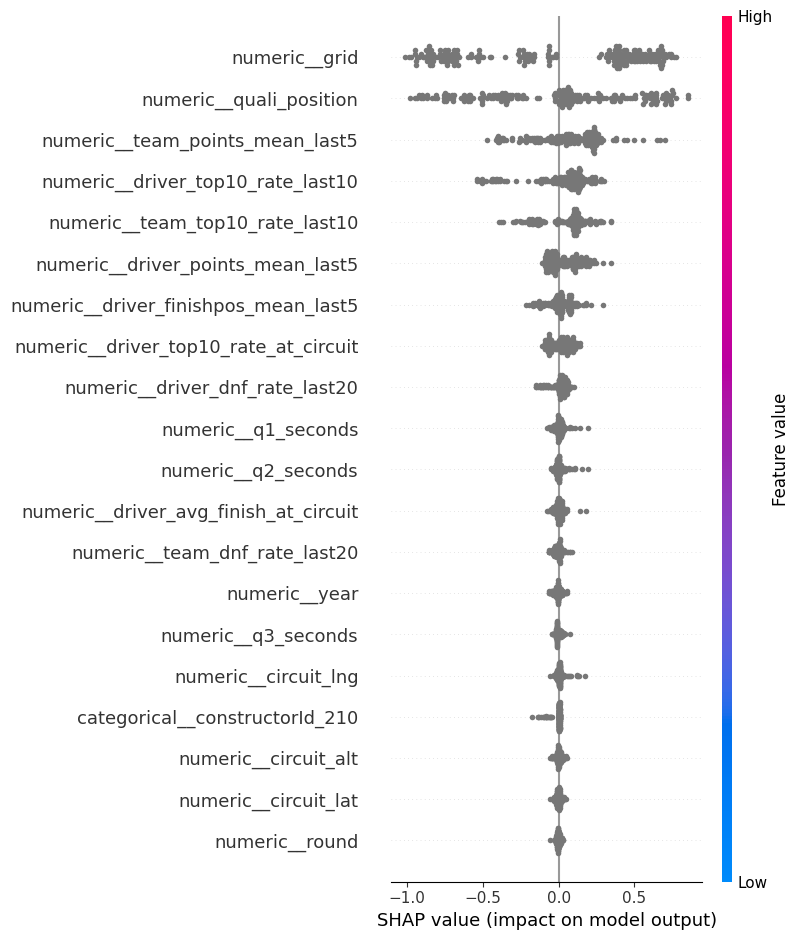

In [11]:
# Optional SHAP (small sample). Guarded to avoid hard failure if SHAP is unavailable.
try:
    import shap

    sample = splits["val"][feature_columns].head(200)
    sample_processed = preprocessor.transform(sample)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(sample_processed)
    shap.summary_plot(shap_values, sample_processed, feature_names=feature_names)
except ImportError:
    print("SHAP is not installed. Install from requirements.txt to enable explanations.")


## 9) Save artifacts (model + preprocess + metadata JSON in `artifacts/`)

In [12]:
from src.train import save_artifacts
from src.utils import utc_timestamp

metadata = {
    "task": "top10",
    "training_years": {
        "min_train_year": MIN_TRAIN_YEAR,
        "train_end_year": TRAIN_END_YEAR,
        "val_year": VAL_YEAR,
        "test_start_year": TEST_START_YEAR,
    },
    "features_used": feature_columns,
    "dataset_files_used": csv_files,
    "timestamp": utc_timestamp(),
}

artifact_paths = save_artifacts(
    trained=trained,
    prefix="top10",
    artifacts_dir=ARTIFACTS_DIR,
    metadata=metadata,
)
artifact_paths


{'model_path': '/home/asen/Work/Uni Work/Година 3/Семестър 6/Програмиране за Мобилни Устройства/Data_Science_and_ML_part/artifacts/top10_model.joblib',
 'pipeline_path': '/home/asen/Work/Uni Work/Година 3/Семестър 6/Програмиране за Мобилни Устройства/Data_Science_and_ML_part/artifacts/top10_pipeline.joblib',
 'metadata_path': '/home/asen/Work/Uni Work/Година 3/Семестър 6/Програмиране за Мобилни Устройства/Data_Science_and_ML_part/artifacts/top10_metadata.json'}

## 10) Inference demo

In [ ]:
from src.inference_demo import predict_race_probabilities

sample_race_id = int(feature_df.loc[feature_df["year"] >= 2024, "raceId"].dropna().iloc[0])

race_predictions = predict_race_probabilities(
    pipeline=pipeline,
    feature_df=feature_df, 
    feature_columns=feature_columns,
    race_id=sample_race_id,
    top_n=20,
)

race_predictions.head(10)


,raceId,year,round,driverId,driver_name,constructorId,constructor_name,grid,quali_position,predicted_probability
0,1121,2024,1,830,Max Verstappen,9,Red Bull,1.0,1.0,0.868872
1,1121,2024,1,844,Charles Leclerc,6,Ferrari,2.0,2.0,0.845159
2,1121,2024,1,832,Carlos Sainz,6,Ferrari,4.0,4.0,0.804010
3,1121,2024,1,4,Fernando Alonso,117,Aston Martin,6.0,6.0,0.792719
4,1121,2024,1,847,George Russell,131,Mercedes,3.0,3.0,0.782072
5,1121,2024,1,815,Sergio Pérez,9,Red Bull,5.0,5.0,0.772006
6,1121,2024,1,846,Lando Norris,1,McLaren,7.0,7.0,0.769182
7,1121,2024,1,1,Lewis Hamilton,131,Mercedes,9.0,9.0,0.753100
8,1121,2024,1,857,Oscar Piastri,1,McLaren,8.0,8.0,0.694077
9,1121,2024,1,840,Lance Stroll,117,Aston Martin,12.0,12.0,0.577964
